In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

In [3]:
df = pd.read_csv(r'C:\Users\Alex\Documents\testing\used-cars\capstone_part_1_final.csv')

In [4]:
df = df[df.mileage.notna()]
df = df[df.first_registration <= 2022]
df = df[df.first_registration >= 1955]
# df2.isna().mean().sort_values()

In [5]:
spain = df[df['location'].str.endswith('ES').fillna(False)]

# Filter
spain = spain[spain['price'].notna()]
spain = spain[spain['gearbox'].notna()]
spain = spain[spain['fuel_type'].notna()]

# Remove columns
spain = spain.loc[:, spain.isna().mean() <= 0.2]


In [6]:
# remove price outliers
spain = spain[spain.price <= 50000]
# spain = spain[spain.first_registration >= 2006]

In [7]:
spain.columns

Index(['make_model', 'short_description', 'make', 'model', 'location', 'price',
       'body_type', 'type', 'doors', 'country_version', 'offer_number',
       'warranty', 'mileage', 'first_registration', 'gearbox', 'fuel_type',
       'colour', 'desc', 'seller', 'power', 'engine_size', 'fuel_consumption'],
      dtype='object')

In [8]:
die = spain[spain.fuel_type == 'Diesel']
gas = spain[spain.fuel_type == 'Benzine']

gas = gas[gas.first_registration >= 2006]
die = die[die.first_registration >= 2015]

In [9]:
gas.price.mean()

17383.25744047619

In [10]:
die.price.mean()

18565.411628980157

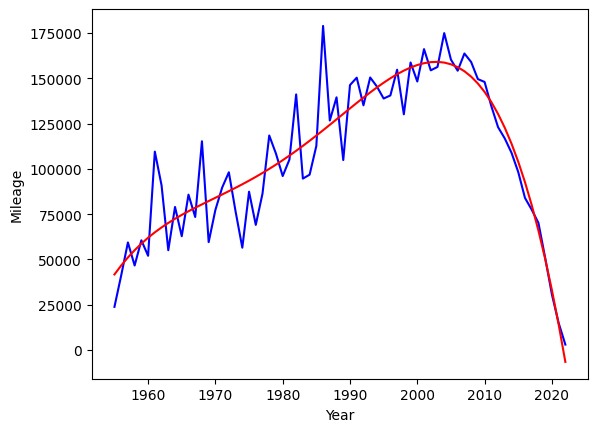

In [11]:
average_mileage_per_year = df.groupby('first_registration')['mileage'].mean()
x = df['first_registration'].unique()
x.sort()
y = average_mileage_per_year.loc[x]

# Calculate coefficients for the line of best fit
mileage_coefficients = np.polyfit(x, y, 4)
mileage_fit = np.polyval(mileage_coefficients, x)

plt.plot(x, y, 'b-')
plt.plot(x, mileage_fit, 'r-')

plt.xlabel('Year')
plt.ylabel('Mileage')
plt.show()

In [12]:
df.loc[9000]

make_model                                                       Peugeot 308
short_description                            BlueHDi 130 S&S SW Allure MY 20
make                                                                 Peugeot
model                                                                    308
location                           Via Zanica 58 /H,  24126 Bergamo - Bg, IT
price                                                                21900.0
body_type                                                      Station wagon
type                                                                    Used
doors                                                                    5.0
country_version                                                          NaN
offer_number                                                         5769497
warranty                                                           12 months
mileage                                                              33954.0

In [22]:
spain.groupby('make')['mileage'].mean().sort_values()

make
Dacia             55936.285928
Ford              61405.722008
Fiat              64780.363785
Hyundai           67583.904762
Nissan            79381.130178
Peugeot           87785.188797
Opel              90136.953020
SEAT              91732.178042
Skoda             94077.930769
Renault           95834.576389
Toyota            96693.679814
Mercedes-Benz     97494.512887
Volvo            115478.105058
Name: mileage, dtype: float64

In [14]:
spain.groupby('body_type')['mileage'].mean().sort_values()

body_type
Sedan                75239.510532
Off-Road/Pick-up     77395.264489
Compact              83468.772336
Station wagon        85953.588805
Convertible          98242.750557
Coupe               100707.396861
Name: mileage, dtype: float64

In [16]:
(spain.groupby('make')['price'].mean()/spain.groupby('make')['mileage'].mean()).sort_values()


make
Renault          0.145128
Volvo            0.158474
Opel             0.158773
Skoda            0.162348
Toyota           0.175901
SEAT             0.179773
Peugeot          0.185109
Nissan           0.210116
Dacia            0.212276
Fiat             0.220221
Hyundai          0.255587
Mercedes-Benz    0.281152
Ford             0.393188
dtype: float64

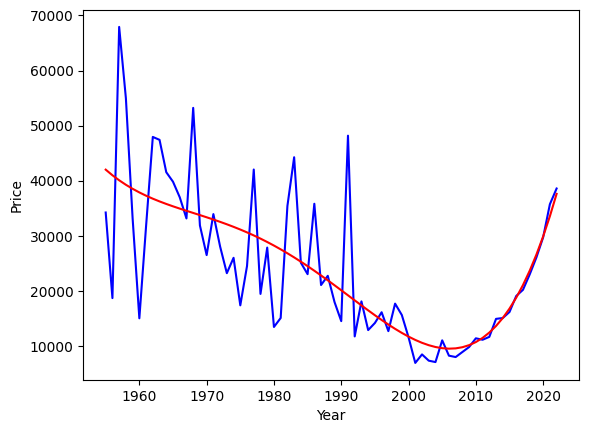

In [17]:
average_mileage_per_year = df.groupby('first_registration')['price'].mean()
x = df['first_registration'].unique()
x.sort()
y = average_mileage_per_year.loc[x]

price_coefficients = np.polyfit(x, y, 4)
price_fit = np.polyval(price_coefficients, x)

plt.plot(x, y, 'b-')
plt.plot(x, price_fit, 'r-')

plt.xlabel('Year')
plt.ylabel('Price')
plt.show()

In [18]:
poly = np.poly1d(price_coefficients)
derivative = poly.deriv()

x_value = fsolve(derivative, 2050) 

print(f"The value of x where dy/dx = 0 is {x_value}")


The value of x where dy/dx = 0 is [2006.1317891]


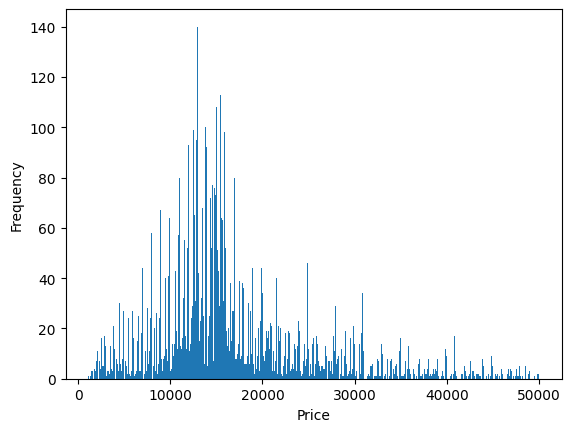

In [19]:
spain.price.plot(kind='hist', bins=500)
plt.xlabel('Price')
plt.show()
